<a href="https://colab.research.google.com/github/Shagun789/ANN/blob/main/Mutation_impact_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

url = "https://huggingface.co/datasets/ICML2022/ProteinGym/resolve/main/ProteinGym_substitutions/BRCA1_HUMAN_Findlay_2018.csv"

df = pd.read_csv(url)

df.head(17)

,mutant,DMS_score,DMS_score_bin
0,M1I,-2.502128,0
1,M1V,-2.025645,0
2,M1T,-1.656569,0
3,M1R,-2.481580,0
4,M1L,-2.516529,0
5,M1K,-1.636700,0
6,D2N,-0.682954,1
7,D2A,-0.180782,1
8,D2E,0.088696,1
9,D2H,-1.473831,0


In [6]:
print(df.columns)

Index(['mutant', 'DMS_score', 'DMS_score_bin'], dtype='object')


In [7]:
df.isnull().sum()

,0
mutant,0
DMS_score,0
DMS_score_bin,0


In [8]:
##No missing values

In [10]:
df = df[["mutant","DMS_score_bin"]]   #we will only keep the import columns

In [11]:
df.head(3)

,mutant,DMS_score_bin
0,M1I,0
1,M1V,0
2,M1T,0


In [12]:
df.head(20)

,mutant,DMS_score_bin
0,M1I,0
1,M1V,0
2,M1T,0
3,M1R,0
4,M1L,0
5,M1K,0
6,D2N,1
7,D2A,1
8,D2E,1
9,D2H,0


In [14]:
#assign input and labels
X = df["mutant"]
y = df["DMS_score_bin"]

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(X)
X_seq = tokenizer.texts_to_sequences(X)

In [19]:
##padding---for the same input length
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
X_pad = pad_sequences(
    X_seq,
    maxlen=10,
    padding="post"
)

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Bidirectional,LSTM,Dense

model = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=32
    ),
    Bidirectional(LSTM(64)),
    Dense(32,activation="relu"),
    Dense(1,activation="sigmoid")
])

In [29]:
##Build and compile the model
model.build(input_shape=(None,10))

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,817 (214.13 KB)

 Trainable params: 54,817 (214.13 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.7291 - loss: 0.6028 - val_accuracy: 0.7391 - val_loss: 0.5731
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7427 - loss: 0.5647 - val_accuracy: 0.7391 - val_loss: 0.5629
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7427 - loss: 0.5525 - val_accuracy: 0.7391 - val_loss: 0.5390
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7502 - loss: 0.5400 - val_accuracy: 0.7500 - val_loss: 0.5162
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7549 - loss: 0.5245 - val_accuracy: 0.7446 - val_loss: 0.5180
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7570 - loss: 0.5159 - val_accuracy: 0.7446 - val_loss: 0.5081
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7631 - loss: 0.5015 - val_accuracy: 0.7364 - val_loss: 0.5142
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7788 - loss: 0.4891 - val_accuracy: 0.7418 - v

In [32]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7174 - loss: 0.5398 
Test Accuracy: 0.717391312122345


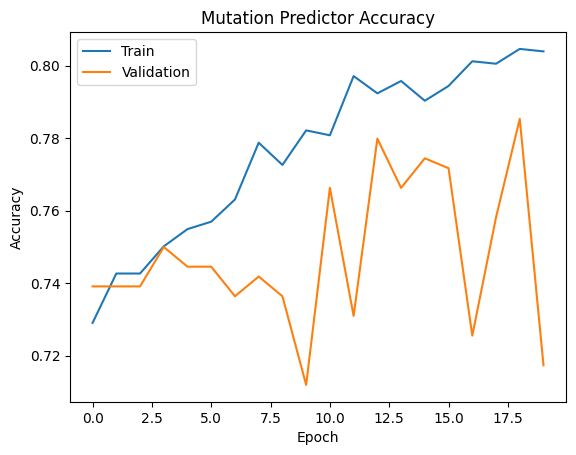

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Mutation Predictor Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

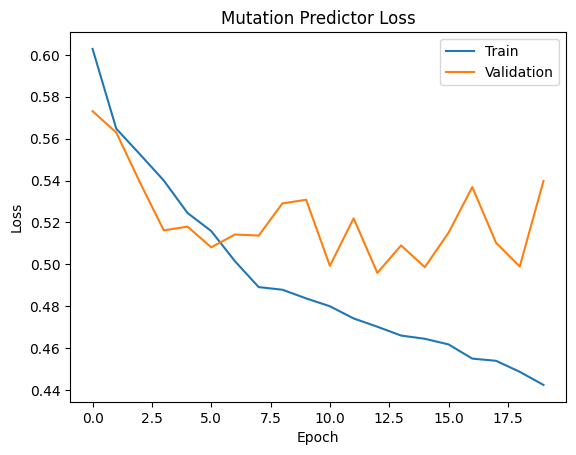

In [34]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Mutation Predictor Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [37]:
new_mutation = ["A123T"]
seq = tokenizer.texts_to_sequences(new_mutation)
seq_pad = pad_sequences(seq, maxlen=10, padding="post")
prediction = model.predict(seq_pad)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.848072]]


In [38]:
if prediction[0][0] > 0.5:
    print("Non-Harmful Mutation")
else:
    print("Harmful Mutation")

Non-Harmful Mutation
